<a href="https://colab.research.google.com/github/bhv8055/StudentPerformance/blob/main/StudentAssessmentperformace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [7]:
import os

# Assuming the CSV file is named 'StudentsPerformance.csv' within the downloaded directory
csv_file_path = os.path.join(path, 'StudentsPerformance.csv')
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to confirm
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### Data Exploration

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [11]:
display(df.describe())

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Distribution of Scores

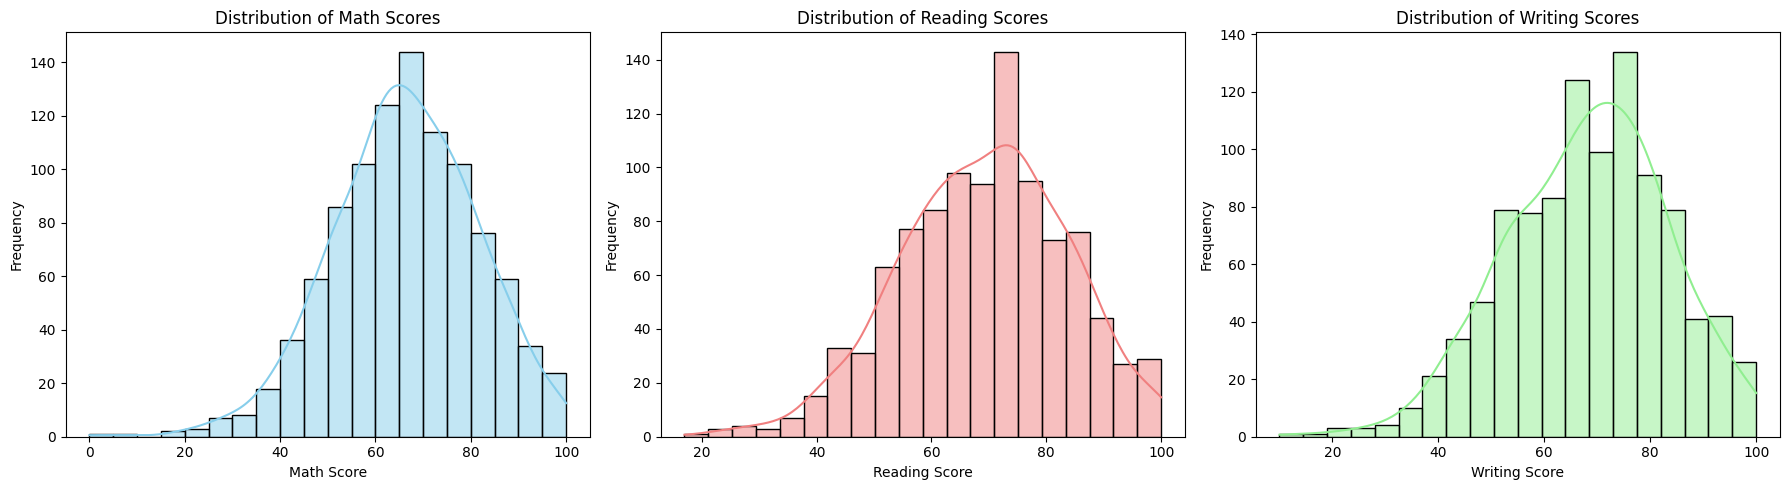

In [12]:
# Plotting histograms for each score
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Reading Scores')
plt.xlabel('Reading Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Writing Scores')
plt.xlabel('Writing Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Average Math Scores by Gender

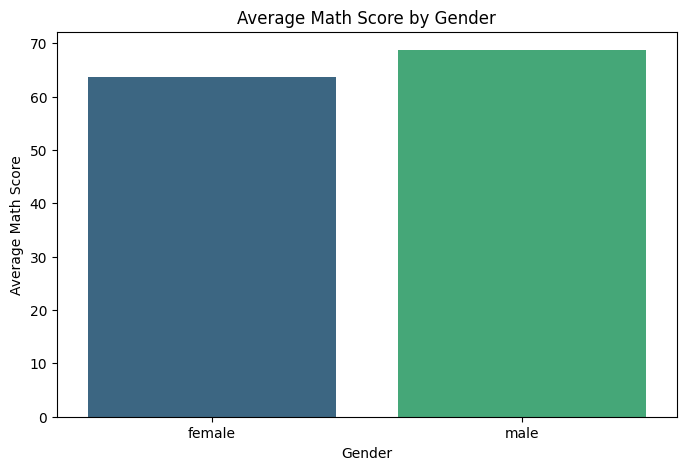

In [14]:
avg_math_score_gender = df.groupby('gender')['math score'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='math score', data=avg_math_score_gender, palette='viridis', hue='gender', legend=False)
plt.title('Average Math Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Math Score')
plt.show()

### Average Math Scores by Test Preparation Course

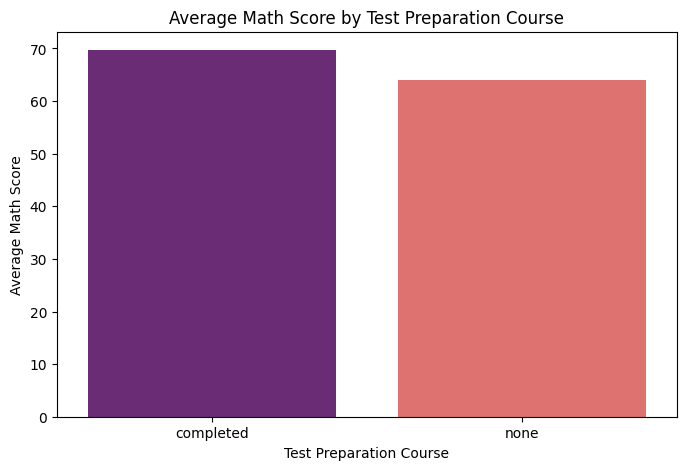

In [15]:
avg_math_score_prep = df.groupby('test preparation course')['math score'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='test preparation course', y='math score', data=avg_math_score_prep, palette='magma', hue='test preparation course', legend=False)
plt.title('Average Math Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Math Score')
plt.show()

### Math Scores Distribution by Parental Level of Education

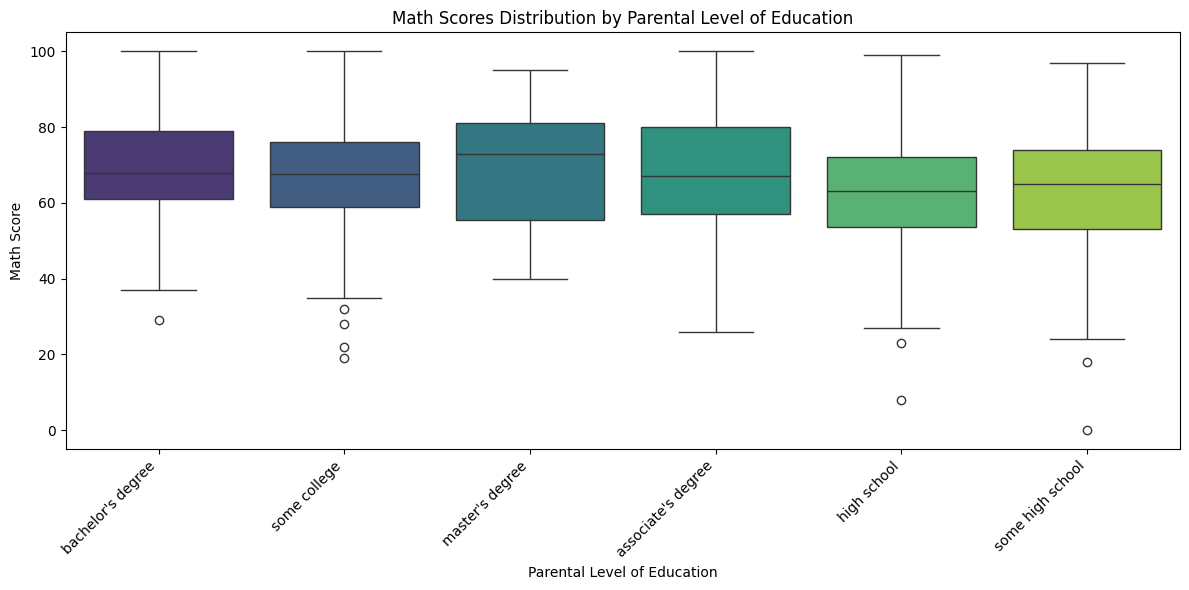

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental level of education', y='math score', data=df, palette='viridis', hue='parental level of education', legend=False)
plt.title('Math Scores Distribution by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Math Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Correlation Matrix of Scores

In [18]:
score_columns = ['math score', 'reading score', 'writing score']
correlation_matrix = df[score_columns].corr()
display(correlation_matrix)

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [20]:
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

display(df_encoded.head())

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


### Splitting Data into Training and Testing Sets

Now, we'll split our `df_encoded` DataFrame into features (X) and the target variable (y), and then divide these into training and testing sets.

In [21]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# The target variable is 'math score'
X = df_encoded.drop('math score', axis=1)
y = df_encoded['math score']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 14)
Shape of X_test: (200, 14)
Shape of y_train: (800,)
Shape of y_test: (200,)


### Training a Linear Regression Model

Now we'll train a Linear Regression model to predict the 'math score' using our prepared training data.

In [22]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression model trained successfully!
Model coefficients: [ 0.23602256  0.72414793 13.06488386  0.3593228  -0.62561715 -0.61323624
  4.89264896 -0.71690113  0.92931227 -1.40048884  0.99885615  0.75647016
  3.51007489  3.28964236]
Model intercept: -10.912497209409949


### Evaluating the Model Performance

After training, we need to evaluate our model using the test set to understand how well it generalizes to new, unseen data.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 4.21
Mean Squared Error (MSE): 29.10
Root Mean Squared Error (RMSE): 5.39
R-squared (R2) Score: 0.88


### Visualizing Actual vs. Predicted Math Scores

To further understand our model's performance, let's visualize the relationship between the actual math scores and our model's predicted math scores using a scatter plot.

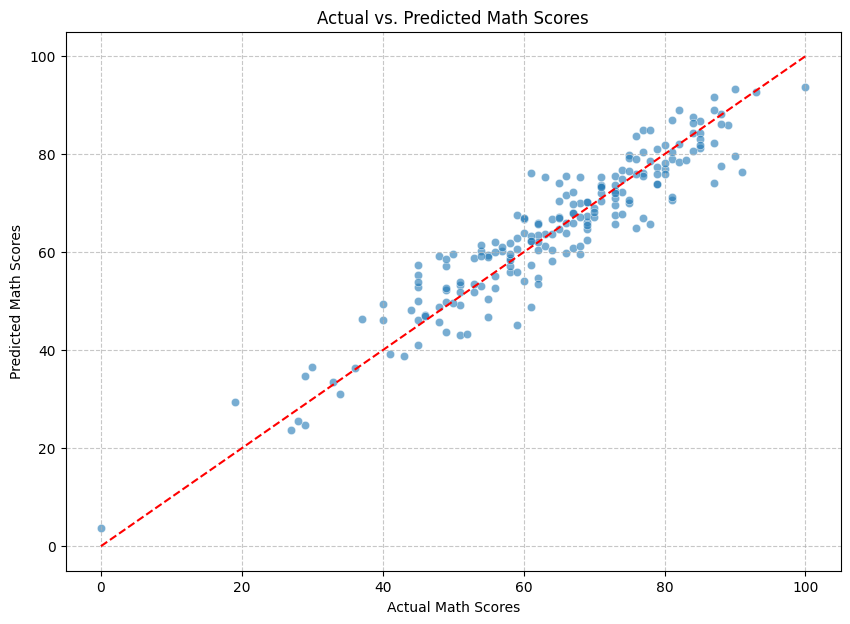

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.title('Actual vs. Predicted Math Scores')
plt.xlabel('Actual Math Scores')
plt.ylabel('Predicted Math Scores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Feature Importance Analysis

Let's examine the coefficients of our Linear Regression model to understand the importance of each feature in predicting math scores. The absolute value of a coefficient indicates the strength of the relationship between the feature and the target variable.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the training data
feature_names = X_train.columns

# Get the coefficients from the trained model
coefficients = model.coef_

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the features by the absolute magnitude of their coefficients for better understanding
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

display(feature_importance.drop(columns='Abs_Coefficient'))

,Feature,Coefficient
2,gender_male,13.064884
6,race/ethnicity_group E,4.892649
12,lunch_standard,3.510075
13,test preparation course_none,3.289642
9,parental level of education_master's degree,-1.400489
10,parental level of education_some college,0.998856
8,parental level of education_high school,0.929312
11,parental level of education_some high school,0.756470
1,writing score,0.724148
7,parental level of education_bachelor's degree,-0.716901


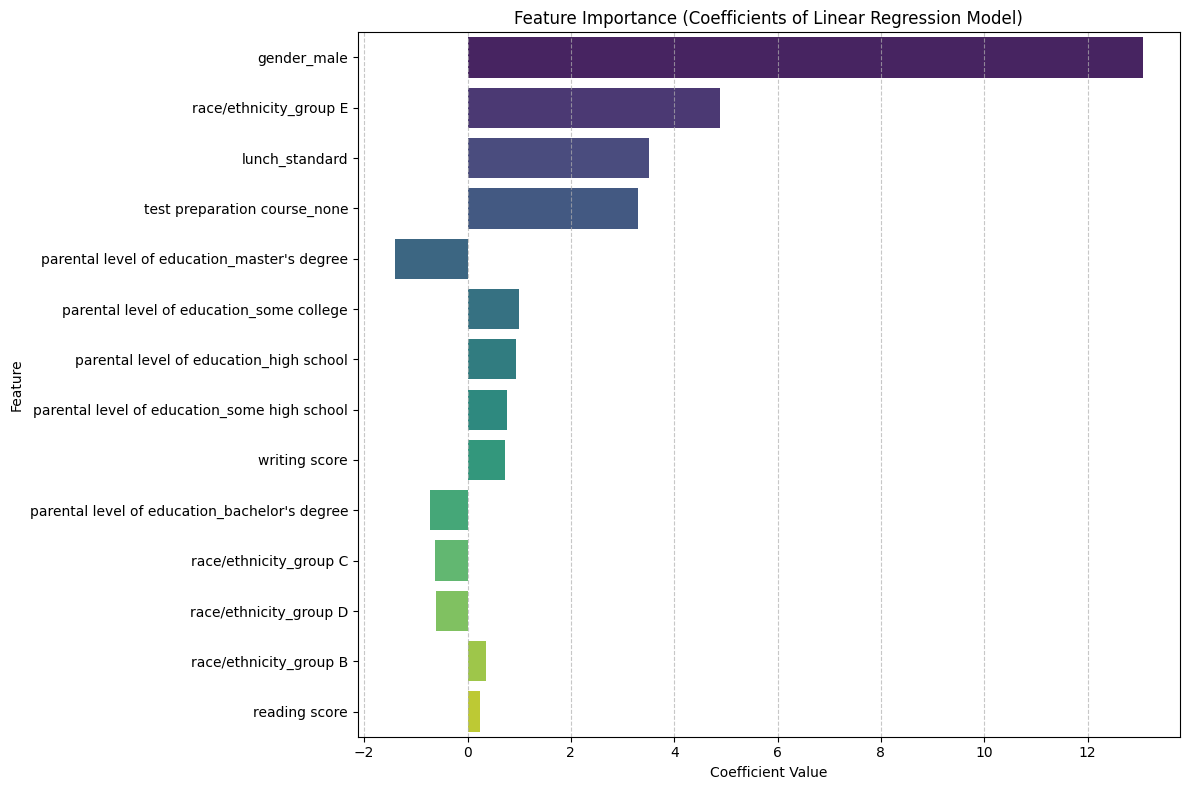

In [28]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Coefficients of Linear Regression Model)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparing with a RandomForestRegressor Model

Let's train a RandomForestRegressor and evaluate its performance to see if it can achieve better results than our Linear Regression model.

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
# Using random_state for reproducibility
rf_model = RandomForestRegressor(random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully!")

RandomForestRegressor model trained successfully!


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the RandomForestRegressor
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for RandomForestRegressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"RandomForestRegressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"RandomForestRegressor - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"RandomForestRegressor - R-squared (R2) Score: {r2_rf:.2f}")

RandomForestRegressor - Mean Absolute Error (MAE): 4.74
RandomForestRegressor - Mean Squared Error (MSE): 36.70
RandomForestRegressor - Root Mean Squared Error (RMSE): 6.06
RandomForestRegressor - R-squared (R2) Score: 0.85


### Model Performance Comparison

Now, let's compare the evaluation metrics of the Linear Regression model with the RandomForestRegressor model.

In [31]:
import pandas as pd

# Create a DataFrame to store the comparison
comparison_data = {
    'Model': ['Linear Regression', 'RandomForestRegressor'],
    'MAE': [mae, mae_rf],
    'MSE': [mse, mse_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
}

performance_comparison_df = pd.DataFrame(comparison_data)

display(performance_comparison_df.set_index('Model'))

,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,4.214763,29.095170,5.393994,0.880433
RandomForestRegressor,4.740643,36.695657,6.057694,0.849199


### Hyperparameter Tuning for RandomForestRegressor

We will use `GridSearchCV` to systematically work through multiple combinations of parameter tunes, cross-validating as it goes to determine the best model.

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
GridSearchCV completed.


In [33]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best R2 score from GridSearchCV (on validation sets): {best_score:.4f}")

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best R2 score from GridSearchCV (on validation sets): 0.8179


### Evaluate Tuned RandomForestRegressor

Now, let's train a new RandomForestRegressor model with the best parameters found by GridSearchCV and evaluate its performance on the test set.

In [34]:
# Train a new RandomForestRegressor with the best parameters
rf_tuned_model = RandomForestRegressor(**best_params, random_state=42)
rf_tuned_model.fit(X_train, y_train)

# Make predictions on the test set with the tuned model
y_pred_rf_tuned = rf_tuned_model.predict(X_test)

# Calculate evaluation metrics for the tuned RandomForestRegressor
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned RandomForestRegressor - Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"Tuned RandomForestRegressor - Mean Squared Error (MSE): {mse_rf_tuned:.2f}")
print(f"Tuned RandomForestRegressor - Root Mean Squared Error (RMSE): {rmse_rf_tuned:.2f}")
print(f"Tuned RandomForestRegressor - R-squared (R2) Score: {r2_rf_tuned:.2f}")

Tuned RandomForestRegressor - Mean Absolute Error (MAE): 5.08
Tuned RandomForestRegressor - Mean Squared Error (MSE): 44.35
Tuned RandomForestRegressor - Root Mean Squared Error (RMSE): 6.66
Tuned RandomForestRegressor - R-squared (R2) Score: 0.82


### Final Model Performance Comparison

Let's add the tuned RandomForestRegressor to our comparison table.

In [35]:
# Append the tuned model's performance to the comparison DataFrame
comparison_data_tuned = {
    'Model': ['Linear Regression', 'RandomForestRegressor', 'RandomForestRegressor (Tuned)'],
    'MAE': [mae, mae_rf, mae_rf_tuned],
    'MSE': [mse, mse_rf, mse_rf_tuned],
    'RMSE': [rmse, rmse_rf, rmse_rf_tuned],
    'R2 Score': [r2, r2_rf, r2_rf_tuned]
}

performance_comparison_df_tuned = pd.DataFrame(comparison_data_tuned)

display(performance_comparison_df_tuned.set_index('Model'))

,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,4.214763,29.095170,5.393994,0.880433
RandomForestRegressor,4.740643,36.695657,6.057694,0.849199
RandomForestRegressor (Tuned),5.076841,44.349658,6.659554,0.817745


### Overfitting Check: Training vs. Test Error

To investigate potential overfitting, we will compare the performance metrics (MAE, MSE, RMSE, R2 Score) of each model on both the training and test datasets. A significant discrepancy (e.g., much better performance on training data than on test data) could indicate overfitting.

In [36]:
# --- Calculate Training Metrics for Linear Regression ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_train_lr = model.predict(X_train)
mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)

# --- Calculate Training Metrics for RandomForestRegressor ---
y_pred_train_rf = rf_model.predict(X_train)
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)

# --- Calculate Training Metrics for Tuned RandomForestRegressor ---
y_pred_train_rf_tuned = rf_tuned_model.predict(X_train)
mae_train_rf_tuned = mean_absolute_error(y_train, y_pred_train_rf_tuned)
mse_train_rf_tuned = mean_squared_error(y_train, y_pred_train_rf_tuned)
rmse_train_rf_tuned = np.sqrt(mse_train_rf_tuned)
r2_train_rf_tuned = r2_score(y_train, y_pred_train_rf_tuned)

print("Training metrics calculated for all models.")

Training metrics calculated for all models.


### Comprehensive Model Performance Comparison (Training vs. Test)

Let's compile all the training and test performance metrics into a single table for a clear comparison.

In [37]:
import pandas as pd

comparison_data_full = {
    'Model': [
        'Linear Regression',
        'Linear Regression (Train)',
        'RandomForestRegressor',
        'RandomForestRegressor (Train)',
        'RandomForestRegressor (Tuned)',
        'RandomForestRegressor (Tuned) (Train)'
    ],
    'MAE': [
        mae, mae_train_lr,
        mae_rf, mae_train_rf,
        mae_rf_tuned, mae_train_rf_tuned
    ],
    'MSE': [
        mse, mse_train_lr,
        mse_rf, mse_train_rf,
        mse_rf_tuned, mse_train_rf_tuned
    ],
    'RMSE': [
        rmse, rmse_train_lr,
        rmse_rf, rmse_train_rf,
        rmse_rf_tuned, rmse_train_rf_tuned
    ],
    'R2 Score': [
        r2, r2_train_lr,
        r2_rf, r2_train_rf,
        r2_rf_tuned, r2_train_rf_tuned
    ]
}

full_performance_comparison_df = pd.DataFrame(comparison_data_full)

display(full_performance_comparison_df.set_index('Model'))

,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,4.214763,29.095170,5.393994,0.880433
Linear Regression (Train),4.266712,28.334870,5.323051,0.874317
RandomForestRegressor,4.740643,36.695657,6.057694,0.849199
RandomForestRegressor (Train),1.851087,5.399345,2.323649,0.976051
RandomForestRegressor (Tuned),5.076841,44.349658,6.659554,0.817745
RandomForestRegressor (Tuned) (Train),1.837530,5.395543,2.322831,0.976067


### Residuals Analysis for Linear Regression Model

Analyzing residuals helps to check the assumptions of linear regression and identify potential issues with the model, such as non-linearity, heteroscedasticity, or outliers. Ideally, residuals should be randomly distributed around zero with a constant variance, and their distribution should be approximately normal.

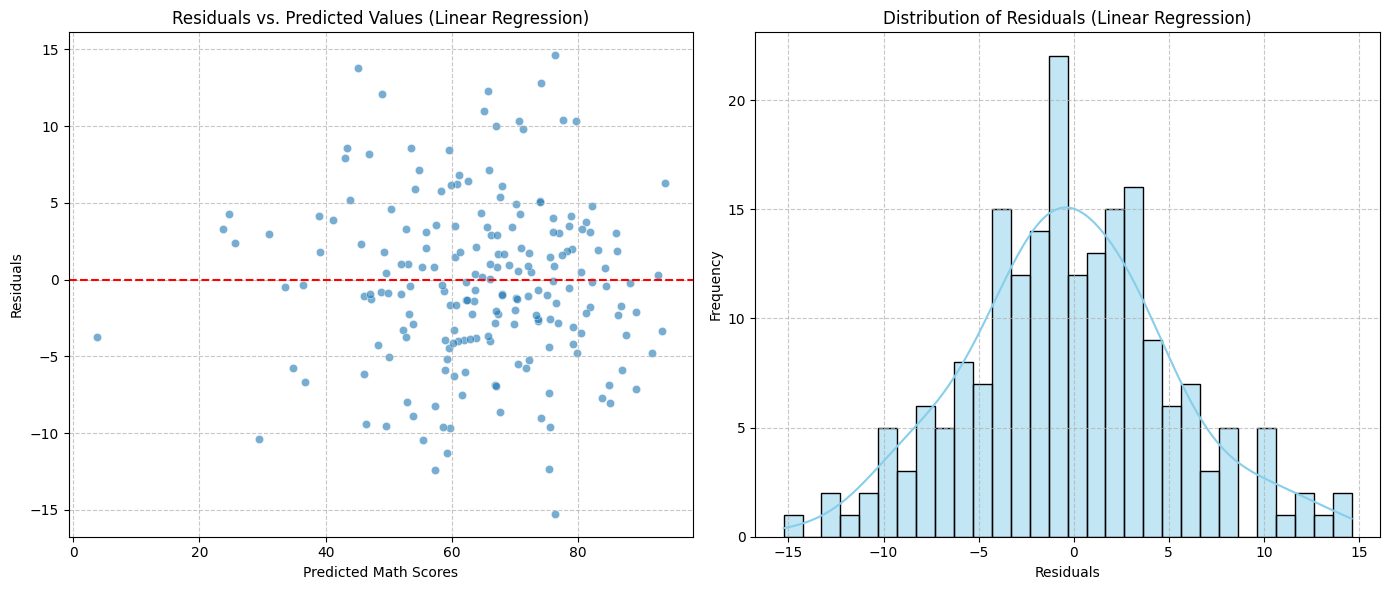

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(14, 6))

# Scatter plot of residuals vs. predicted values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Linear Regression)')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Residuals (Linear Regression)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Distribution of Absolute Errors for Linear Regression Model

To understand the magnitude of our model's prediction errors, let's look at the distribution of absolute errors. This helps to see how frequently large or small errors occur.

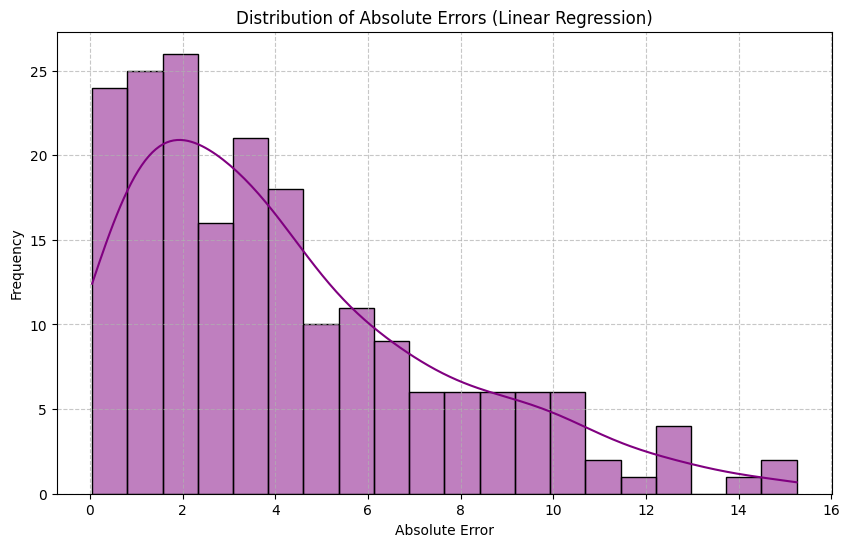

In [39]:
abs_errors = np.abs(residuals)

plt.figure(figsize=(10, 6))
sns.histplot(abs_errors, kde=True, bins=20, color='purple')
plt.title('Distribution of Absolute Errors (Linear Regression)')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Residuals Analysis for RandomForestRegressor Models

Similar to the Linear Regression model, we will now visualize the residuals for both the untuned and tuned RandomForestRegressor models. This comparison will highlight differences in how each model handles prediction errors.

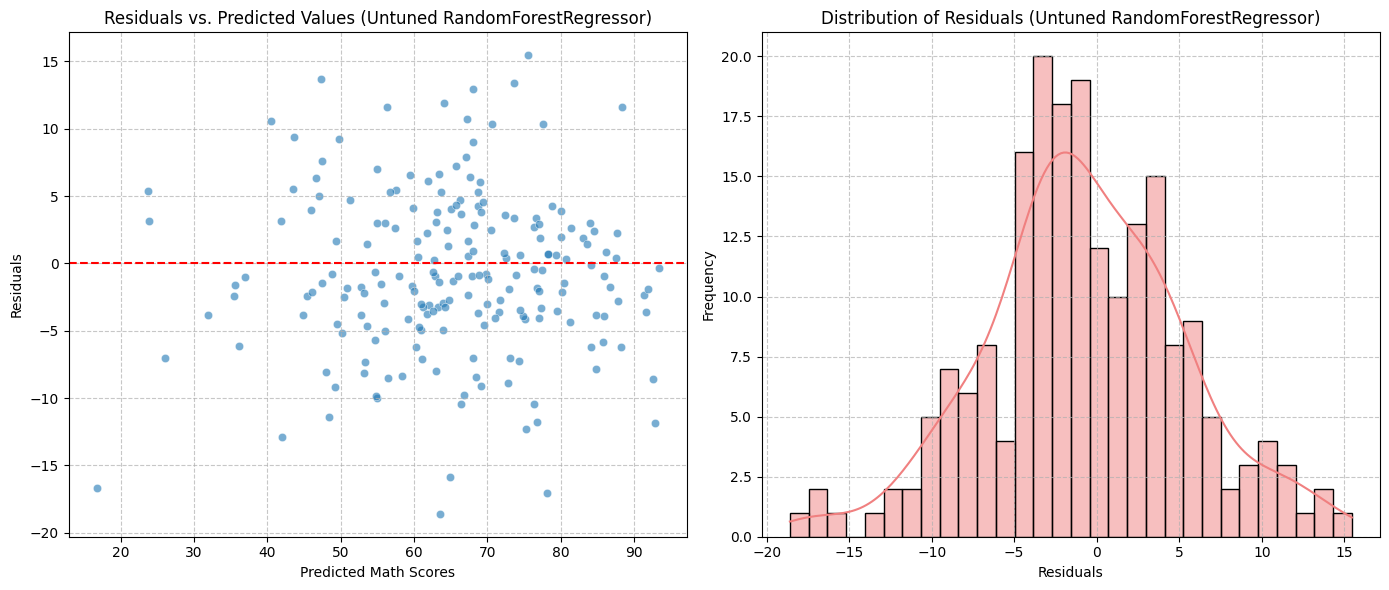

In [40]:
# Residuals for Untuned RandomForestRegressor
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(14, 6))

# Scatter plot of residuals vs. predicted values (Untuned RF)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred_rf, y=residuals_rf, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Untuned RandomForestRegressor)')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals (Untuned RF)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals_rf, kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Residuals (Untuned RandomForestRegressor)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

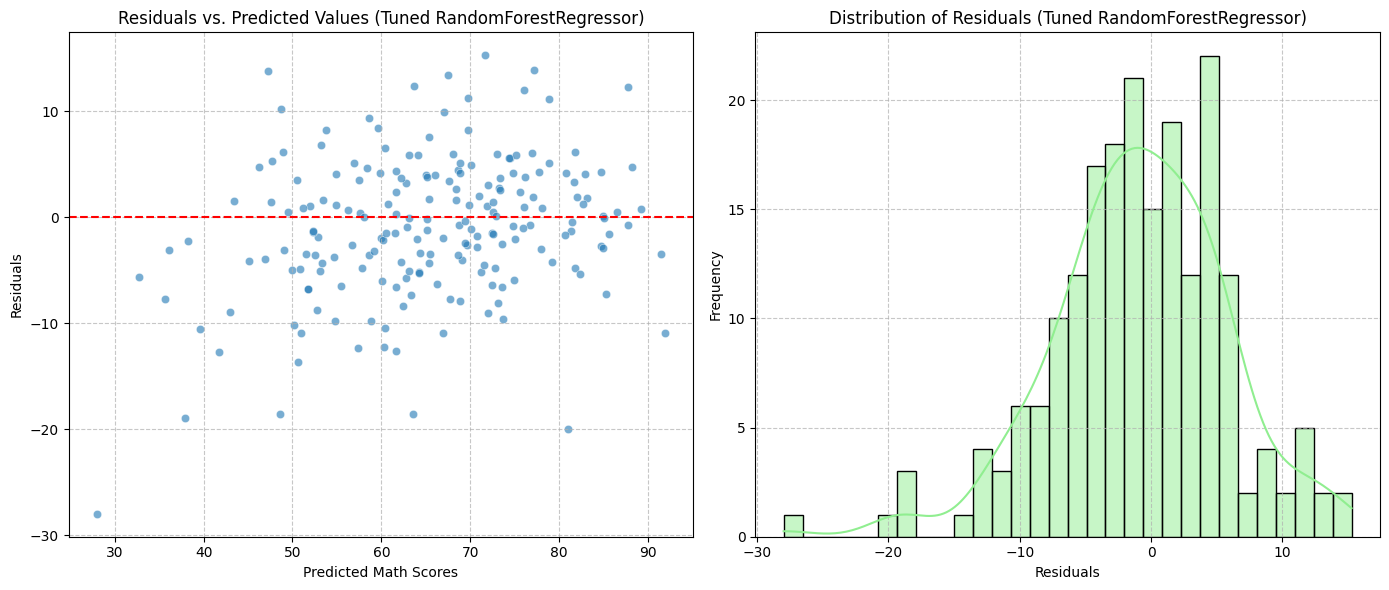

In [41]:
# Residuals for Tuned RandomForestRegressor
residuals_rf_tuned = y_test - y_pred_rf_tuned

plt.figure(figsize=(14, 6))

# Scatter plot of residuals vs. predicted values (Tuned RF)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred_rf_tuned, y=residuals_rf_tuned, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned RandomForestRegressor)')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals (Tuned RF)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals_rf_tuned, kde=True, bins=30, color='lightgreen')
plt.title('Distribution of Residuals (Tuned RandomForestRegressor)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Identifying Data Points with Largest Residuals (Linear Regression)

Let's pinpoint the specific test data points where our Linear Regression model had the largest prediction errors. This can help us understand if there are certain patterns or characteristics in the data that the model struggles to predict accurately.

In [42]:
# Create a DataFrame to hold actual values, predicted values, and residuals
error_analysis_df = pd.DataFrame({
    'Actual_Math_Score': y_test,
    'Predicted_Math_Score': y_pred,
    'Residual': residuals
})

# Sort by the absolute value of the residual to find the largest errors
error_analysis_df['Abs_Residual'] = np.abs(error_analysis_df['Residual'])
largest_errors = error_analysis_df.sort_values(by='Abs_Residual', ascending=False)

# Display the top 10 data points with the largest absolute residuals
print("Top 10 Data Points with Largest Absolute Residuals:")
display(largest_errors.head(10))

# Optionally, display the features of these specific data points
print("Features of the Top 10 Data Points with Largest Absolute Residuals:")
display(X_test.loc[largest_errors.head(10).index])

Top 10 Data Points with Largest Absolute Residuals:


,Actual_Math_Score,Predicted_Math_Score,Residual,Abs_Residual
158,61,76.255711,-15.255711,15.255711
521,91,76.387970,14.612030,14.612030
265,59,45.188276,13.811724,13.811724
859,87,74.184710,12.815290,12.815290
371,45,57.380744,-12.380744,12.380744
318,63,75.318335,-12.318335,12.318335
199,78,65.700592,12.299408,12.299408
867,61,48.914440,12.085560,12.085560
589,48,59.290795,-11.290795,11.290795
767,76,65.033372,10.966628,10.966628


Features of the Top 10 Data Points with Largest Absolute Residuals:


,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
158,86,87,False,True,False,False,False,False,False,False,False,False,True,False
521,86,84,False,False,True,False,False,False,False,False,False,False,True,True
265,42,41,True,False,False,True,False,False,False,False,False,True,False,True
859,73,72,True,False,True,False,False,False,False,False,False,False,False,True
371,73,70,False,False,True,False,False,False,False,False,True,False,False,False
318,71,69,True,True,False,False,False,True,False,False,False,False,True,True
199,79,76,False,True,False,False,False,True,False,False,False,False,False,True
867,42,41,True,True,False,False,False,False,False,False,False,False,True,True
589,66,65,False,False,False,False,False,False,False,False,False,True,True,True
767,62,60,True,True,False,False,False,False,True,False,False,False,True,False


### Summary of Most Frequent Categories in High-Error Instances

Let's analyze the categorical features of these top 10 high-error data points to see if any specific categories are over-represented.

In [43]:
# Get the indices of the top 10 largest errors
top_10_error_indices = largest_errors.head(10).index

# Filter the original DataFrame (df) using these indices
top_error_df = df.loc[top_10_error_indices]

# Identify original categorical columns
categorical_cols_original = df.select_dtypes(include=['object']).columns

# Create a dictionary to store the frequency of each category
category_frequency = {}

for col in categorical_cols_original:
    category_frequency[col] = top_error_df[col].value_counts().to_dict()

# Convert the dictionary to a more readable format, like a DataFrame
summary_df = pd.DataFrame({
    'Category Feature': [col for col, _ in category_frequency.items() for _ in category_frequency[col].keys()],
    'Category Value': [val for _ , val_dict in category_frequency.items() for val in val_dict.keys()],
    'Count in Top 10 Errors': [count for _ , val_dict in category_frequency.items() for count in val_dict.values()]
})

display(summary_df.sort_values(by='Count in Top 10 Errors', ascending=False))

,Category Feature,Category Value,Count in Top 10 Errors
13,test preparation course,none,7
11,lunch,standard,6
0,gender,female,5
1,gender,male,5
2,race/ethnicity,group B,5
6,parental level of education,associate's degree,4
12,lunch,free/reduced,4
3,race/ethnicity,group C,3
14,test preparation course,completed,3
8,parental level of education,bachelor's degree,2


### Math Score Distribution by Test Preparation Course

Let's visualize the distribution of math scores for students who completed a test preparation course versus those who did not, across the entire dataset. This will provide a broader context to our error analysis finding.

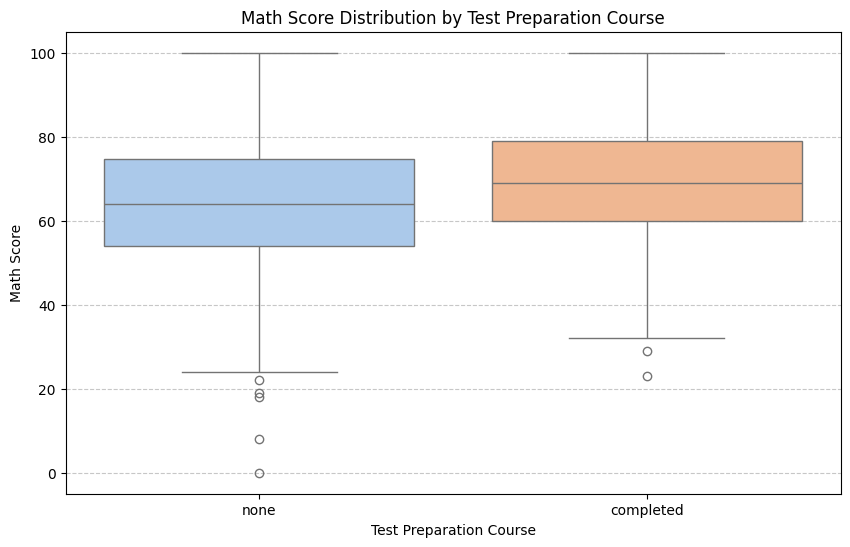

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='test preparation course', y='math score', data=df, palette='pastel', hue='test preparation course', legend=False)
plt.title('Math Score Distribution by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Model Performance on 'Test Preparation Course: None' Subgroup

To quantify how much the model struggles with the 'test preparation course: none' group, let's filter our test set to include only these students and re-evaluate the Linear Regression model's performance on this specific subgroup. This will give us an idea of the performance degradation.

In [45]:
# Filter X_test and y_test for students who did not complete the test preparation course
X_test_no_prep = X_test[X_test['test preparation course_none'] == True]
y_test_no_prep = y_test.loc[X_test_no_prep.index]

# Make predictions on this subgroup
y_pred_no_prep = model.predict(X_test_no_prep)

# Calculate evaluation metrics for the 'no prep' subgroup
mae_no_prep = mean_absolute_error(y_test_no_prep, y_pred_no_prep)
mse_no_prep = mean_squared_error(y_test_no_prep, y_pred_no_prep)
rmse_no_prep = np.sqrt(mse_no_prep)
r2_no_prep = r2_score(y_test_no_prep, y_pred_no_prep)

print("Linear Regression Model Performance on 'Test Preparation Course: None' Subgroup:")
print(f"  Mean Absolute Error (MAE): {mae_no_prep:.2f}")
print(f"  Mean Squared Error (MSE): {mse_no_prep:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_no_prep:.2f}")
print(f"  R-squared (R2) Score: {r2_no_prep:.2f}")

Linear Regression Model Performance on 'Test Preparation Course: None' Subgroup:
  Mean Absolute Error (MAE): 4.57
  Mean Squared Error (MSE): 33.10
  Root Mean Squared Error (RMSE): 5.75
  R-squared (R2) Score: 0.88


### Investigating Interaction Effects: 'Test Preparation Course' and 'Reading Score'

To check for potential interaction effects, we will create a new feature by multiplying `reading score` with the one-hot encoded feature `test preparation course_none`. This new feature will allow the model to capture if the relationship between reading score and math score changes depending on whether a student completed the test preparation course. We will then retrain the Linear Regression model with this new feature.

In [46]:
# Create a copy of the encoded DataFrame to add the interaction term
df_encoded_interaction = df_encoded.copy()

# Create the interaction term: reading score * (test preparation course_none)
# This assumes 'test preparation course_none' is already a boolean/binary column (0 or 1)
df_encoded_interaction['reading_score_x_no_prep'] = df_encoded_interaction['reading score'] * df_encoded_interaction['test preparation course_none']

# Display the head of the new DataFrame to confirm the new feature
display(df_encoded_interaction.head())

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,reading_score_x_no_prep
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True,72
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False,0
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True,95
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True,57
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True,78


### Retraining Linear Regression Model with Interaction Term

Now, we will split the data with the new interaction term into training and testing sets and retrain our Linear Regression model.

In [47]:
# Define features (X_int) and target (y_int) for the model with interaction term
X_int = df_encoded_interaction.drop('math score', axis=1)
y_int = df_encoded_interaction['math score']

# Split the data into training and testing sets
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(X_int, y_int, test_size=0.2, random_state=42)

# Initialize and train a new Linear Regression model
model_int = LinearRegression()
model_int.fit(X_train_int, y_train_int)

print("Linear Regression model with interaction term trained successfully!")

Linear Regression model with interaction term trained successfully!


### Evaluating the New Model Performance (Overall)

Let's evaluate the performance of the Linear Regression model with the interaction term on the entire test set.

In [48]:
# Make predictions on the test set with the new model
y_pred_int = model_int.predict(X_test_int)

# Calculate evaluation metrics
mae_int = mean_absolute_error(y_test_int, y_pred_int)
mse_int = mean_squared_error(y_test_int, y_pred_int)
rmse_int = np.sqrt(mse_int)
r2_int = r2_score(y_test_int, y_pred_int)

print(f"Linear Regression with Interaction Term - MAE: {mae_int:.2f}")
print(f"Linear Regression with Interaction Term - MSE: {mse_int:.2f}")
print(f"Linear Regression with Interaction Term - RMSE: {rmse_int:.2f}")
print(f"Linear Regression with Interaction Term - R2 Score: {r2_int:.2f}")

Linear Regression with Interaction Term - MAE: 4.23
Linear Regression with Interaction Term - MSE: 29.22
Linear Regression with Interaction Term - RMSE: 5.41
Linear Regression with Interaction Term - R2 Score: 0.88


### Evaluating the New Model Performance on 'Test Preparation Course: None' Subgroup

Finally, let's re-evaluate the performance of this new model specifically on the subgroup of students who did not complete the test preparation course to see if the interaction term helped improve predictions for this group.

In [49]:
# Filter X_test_int and y_test_int for students who did not complete the test preparation course
X_test_int_no_prep = X_test_int[X_test_int['test preparation course_none'] == True]
y_test_int_no_prep = y_test_int.loc[X_test_int_no_prep.index]

# Make predictions on this subgroup
y_pred_int_no_prep = model_int.predict(X_test_int_no_prep)

# Calculate evaluation metrics for the 'no prep' subgroup with interaction term
mae_int_no_prep = mean_absolute_error(y_test_int_no_prep, y_pred_int_no_prep)
mse_int_no_prep = mean_squared_error(y_test_int_no_prep, y_pred_int_no_prep)
rmse_int_no_prep = np.sqrt(mse_int_no_prep)
r2_int_no_prep = r2_score(y_test_int_no_prep, y_pred_int_no_prep)

print("Linear Regression Model with Interaction Term Performance on 'Test Preparation Course: None' Subgroup:")
print(f"  Mean Absolute Error (MAE): {mae_int_no_prep:.2f}")
print(f"  Mean Squared Error (MSE): {mse_int_no_prep:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_int_no_prep:.2f}")
print(f"  R-squared (R2) Score: {r2_int_no_prep:.2f}")

Linear Regression Model with Interaction Term Performance on 'Test Preparation Course: None' Subgroup:
  Mean Absolute Error (MAE): 4.59
  Mean Squared Error (MSE): 33.30
  Root Mean Squared Error (RMSE): 5.77
  R-squared (R2) Score: 0.88


### Training and Evaluating an XGBoost Regressor

Given that the Linear Regression model, even with an interaction term, had slightly higher errors for the 'no prep' subgroup, let's explore a more powerful, non-linear model: the XGBoost Regressor. XGBoost (Extreme Gradient Boosting) is known for its performance and ability to capture complex patterns in data.

In [50]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)

# Note: For XGBoost, it's often beneficial to use numerical representations for boolean columns.
# X_train and X_test might still have boolean columns from get_dummies if drop_first=False was used previously.
# Ensure all columns are numeric for XGBoost. (Our previous `df_encoded` already converts them to 0/1)

# Use the original X_train, y_train, X_test, y_test from the Linear Regression step for consistency
# These were derived from df_encoded before adding the interaction term.

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


### Evaluating XGBoost Regressor Performance (Overall)

Let's evaluate the overall performance of the XGBoost model on the test set.

In [51]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"XGBoost Regressor - R2 Score: {r2_xgb:.2f}")

XGBoost Regressor - Mean Absolute Error (MAE): 4.56
XGBoost Regressor - Mean Squared Error (MSE): 35.36
XGBoost Regressor - Root Mean Squared Error (RMSE): 5.95
XGBoost Regressor - R2 Score: 0.85


### Evaluating XGBoost Regressor Performance on 'Test Preparation Course: None' Subgroup

Now, let's critically examine how the XGBoost model performs specifically on the subgroup of students who did not complete the test preparation course. This will tell us if this more advanced model can better handle the instances where our Linear Regression model struggled.

In [52]:
# Filter X_test and y_test for students who did not complete the test preparation course
# We will reuse X_test_no_prep and y_test_no_prep from previous analysis with the Linear Regression model
# These were created from the original X_test before any interaction terms were added.

# Make predictions on this subgroup
y_pred_xgb_no_prep = xgb_model.predict(X_test_no_prep)

# Calculate evaluation metrics for the 'no prep' subgroup with XGBoost
mae_xgb_no_prep = mean_absolute_error(y_test_no_prep, y_pred_xgb_no_prep)
mse_xgb_no_prep = mean_squared_error(y_test_no_prep, y_pred_xgb_no_prep)
rmse_xgb_no_prep = np.sqrt(mse_xgb_no_prep)
r2_xgb_no_prep = r2_score(y_test_no_prep, y_pred_xgb_no_prep)

print("XGBoost Regressor Model Performance on 'Test Preparation Course: None' Subgroup:")
print(f"  Mean Absolute Error (MAE): {mae_xgb_no_prep:.2f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_no_prep:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_no_prep:.2f}")
print(f"  R-squared (R2) Score: {r2_xgb_no_prep:.2f}")

XGBoost Regressor Model Performance on 'Test Preparation Course: None' Subgroup:
  Mean Absolute Error (MAE): 5.04
  Mean Squared Error (MSE): 41.25
  Root Mean Squared Error (RMSE): 6.42
  R-squared (R2) Score: 0.86


### Hyperparameter Tuning for XGBoost Regressor

Since the initial XGBoost model didn't outperform Linear Regression, let's perform hyperparameter tuning using `GridSearchCV` to find a better configuration for the XGBoost Regressor. This might help it better capture complex patterns and improve performance, especially on the 'no prep' subgroup.

In [56]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define a parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Initialize the XGBoost Regressor
xgb_base_estimator = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_base_estimator, param_grid=param_grid_xgb, cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

print("XGBoost GridSearchCV completed.")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
XGBoost GridSearchCV completed.


### Evaluate Tuned XGBoost Regressor

Now, let's evaluate the performance of the XGBoost model with the best parameters found by `GridSearchCV`.

In [57]:
import xgboost as xgb

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best parameters for XGBoost: {best_params_xgb}")
print(f"Best R2 score from GridSearchCV (on validation sets) for XGBoost: {best_score_xgb:.4f}")

# Train a new XGBoost model with the best parameters
xgb_tuned_model = xgb.XGBRegressor(**best_params_xgb, objective='reg:squarederror', random_state=42)
xgb_tuned_model.fit(X_train, y_train)

# Make predictions on the test set with the tuned model
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test)

# Calculate evaluation metrics for the tuned XGBoost Regressor
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"\nTuned XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Tuned XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb_tuned:.2f}")
print(f"Tuned XGBoost Regressor - Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"Tuned XGBoost Regressor - R-squared (R2) Score: {r2_xgb_tuned:.2f}")

Best parameters for XGBoost: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best R2 score from GridSearchCV (on validation sets) for XGBoost: 0.8493

Tuned XGBoost Regressor - Mean Absolute Error (MAE): 4.36
Tuned XGBoost Regressor - Mean Squared Error (MSE): 31.72
Tuned XGBoost Regressor - Root Mean Squared Error (RMSE): 5.63
Tuned XGBoost Regressor - R-squared (R2) Score: 0.87


### Evaluating Tuned XGBoost Regressor Performance on 'Test Preparation Course: None' Subgroup

Let's check if the tuned XGBoost model improved predictions for the 'test preparation course: none' subgroup.

In [63]:
# Make predictions on the 'no prep' subgroup with the tuned XGBoost model
y_pred_xgb_tuned_no_prep = xgb_tuned_model.predict(X_test_no_prep)

# Calculate evaluation metrics for the 'no prep' subgroup with tuned XGBoost
mae_xgb_tuned_no_prep = mean_absolute_error(y_test_no_prep, y_pred_xgb_tuned_no_prep)
mse_xgb_tuned_no_prep = mean_squared_error(y_test_no_prep, y_pred_xgb_tuned_no_prep)
rmse_xgb_tuned_no_prep = np.sqrt(mse_xgb_tuned_no_prep)
r2_xgb_tuned_no_prep = r2_score(y_test_no_prep, y_pred_xgb_tuned_no_prep)

print("Tuned XGBoost Regressor Model Performance on 'Test Preparation Course: None' Subgroup:")
print(f"  Mean Absolute Error (MAE): {mae_xgb_tuned_no_prep:.2f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_tuned_no_prep:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_tuned_no_prep:.2f}")
print(f"  R-squared (R2) Score: {r2_xgb_tuned_no_prep:.2f}")

Tuned XGBoost Regressor Model Performance on 'Test Preparation Course: None' Subgroup:
  Mean Absolute Error (MAE): 4.80
  Mean Squared Error (MSE): 36.87
  Root Mean Squared Error (RMSE): 6.07
  R-squared (R2) Score: 0.87


In [65]:
# Filter X_test and y_test for students who completed the test preparation course
X_test_completed_prep = X_test[X_test['test preparation course_none'] == False]
y_test_completed_prep = y_test.loc[X_test_completed_prep.index]

# Make predictions on this subgroup with the tuned XGBoost model
y_pred_xgb_tuned_completed_prep = xgb_tuned_model.predict(X_test_completed_prep)

# Calculate evaluation metrics for the 'completed prep' subgroup with tuned XGBoost
mae_xgb_tuned_completed_prep = mean_absolute_error(y_test_completed_prep, y_pred_xgb_tuned_completed_prep)
mse_xgb_tuned_completed_prep = mean_squared_error(y_test_completed_prep, y_pred_xgb_tuned_completed_prep)
rmse_xgb_tuned_completed_prep = np.sqrt(mse_xgb_tuned_completed_prep)
r2_xgb_tuned_completed_prep = r2_score(y_test_completed_prep, y_pred_xgb_tuned_completed_prep)

print("Tuned XGBoost Regressor Model Performance on 'Test Preparation Course: Completed' Subgroup:")
print(f"  Mean Absolute Error (MAE): {mae_xgb_tuned_completed_prep:.2f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_tuned_completed_prep:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_tuned_completed_prep:.2f}")
print(f"  R-squared (R2) Score: {r2_xgb_tuned_completed_prep:.2f}")

Tuned XGBoost Regressor Model Performance on 'Test Preparation Course: Completed' Subgroup:
  Mean Absolute Error (MAE): 3.67
  Mean Squared Error (MSE): 23.84
  Root Mean Squared Error (RMSE): 4.88
  R-squared (R2) Score: 0.86


### Comprehensive Subgroup Performance Comparison

Let's compile the performance metrics for both Linear Regression and Tuned XGBoost models on both the 'none' and 'completed' test preparation course subgroups for a clear comparison.

### Feature Importance Comparison: 'No Prep' vs. 'Completed Prep' Subgroups (Tuned XGBoost)

To understand what features drive predictions differently between students who completed the test preparation course and those who did not, we will train separate XGBoost models for each subgroup and compare their feature importances.

In [69]:
# 1. Prepare subgroup training data
X_train_no_prep = X_train[X_train['test preparation course_none'] == True]
y_train_no_prep = y_train.loc[X_train_no_prep.index]

X_train_completed_prep = X_train[X_train['test preparation course_none'] == False]
y_train_completed_prep = y_train.loc[X_train_completed_prep.index]

print(f"Shape of X_train_no_prep: {X_train_no_prep.shape}")
print(f"Shape of X_train_completed_prep: {X_train_completed_prep.shape}")

Shape of X_train_no_prep: (521, 14)
Shape of X_train_completed_prep: (279, 14)


In [70]:
import xgboost as xgb

# 2. Train Tuned XGBoost models for each subgroup
# Reusing the best_params_xgb found during overall tuning

# Model for 'no prep' subgroup
xgb_model_no_prep = xgb.XGBRegressor(**best_params_xgb, objective='reg:squarederror', random_state=42)
xgb_model_no_prep.fit(X_train_no_prep, y_train_no_prep)

# Model for 'completed prep' subgroup
xgb_model_completed_prep = xgb.XGBRegressor(**best_params_xgb, objective='reg:squarederror', random_state=42)
xgb_model_completed_prep.fit(X_train_completed_prep, y_train_completed_prep)

print("XGBoost models trained for both subgroups.")

XGBoost models trained for both subgroups.


In [71]:
# 3. Extract feature importances and create DataFrames

# Feature importance for 'no prep' subgroup model
feature_importance_no_prep = pd.DataFrame({
    'Feature': X_train_no_prep.columns,
    'Importance': xgb_model_no_prep.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Feature importance for 'completed prep' subgroup model
feature_importance_completed_prep = pd.DataFrame({
    'Feature': X_train_completed_prep.columns,
    'Importance': xgb_model_completed_prep.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top features for each
print("Top Features for 'No Prep' Subgroup:")
display(feature_importance_no_prep.head())

print("\nTop Features for 'Completed Prep' Subgroup:")
display(feature_importance_completed_prep.head())

Top Features for 'No Prep' Subgroup:


,Feature,Importance
1,writing score,0.284986
2,gender_male,0.211397
0,reading score,0.200520
12,lunch_standard,0.105160
6,race/ethnicity_group E,0.047094



Top Features for 'Completed Prep' Subgroup:


,Feature,Importance
0,reading score,0.290751
2,gender_male,0.195113
1,writing score,0.132397
12,lunch_standard,0.098811
6,race/ethnicity_group E,0.084022


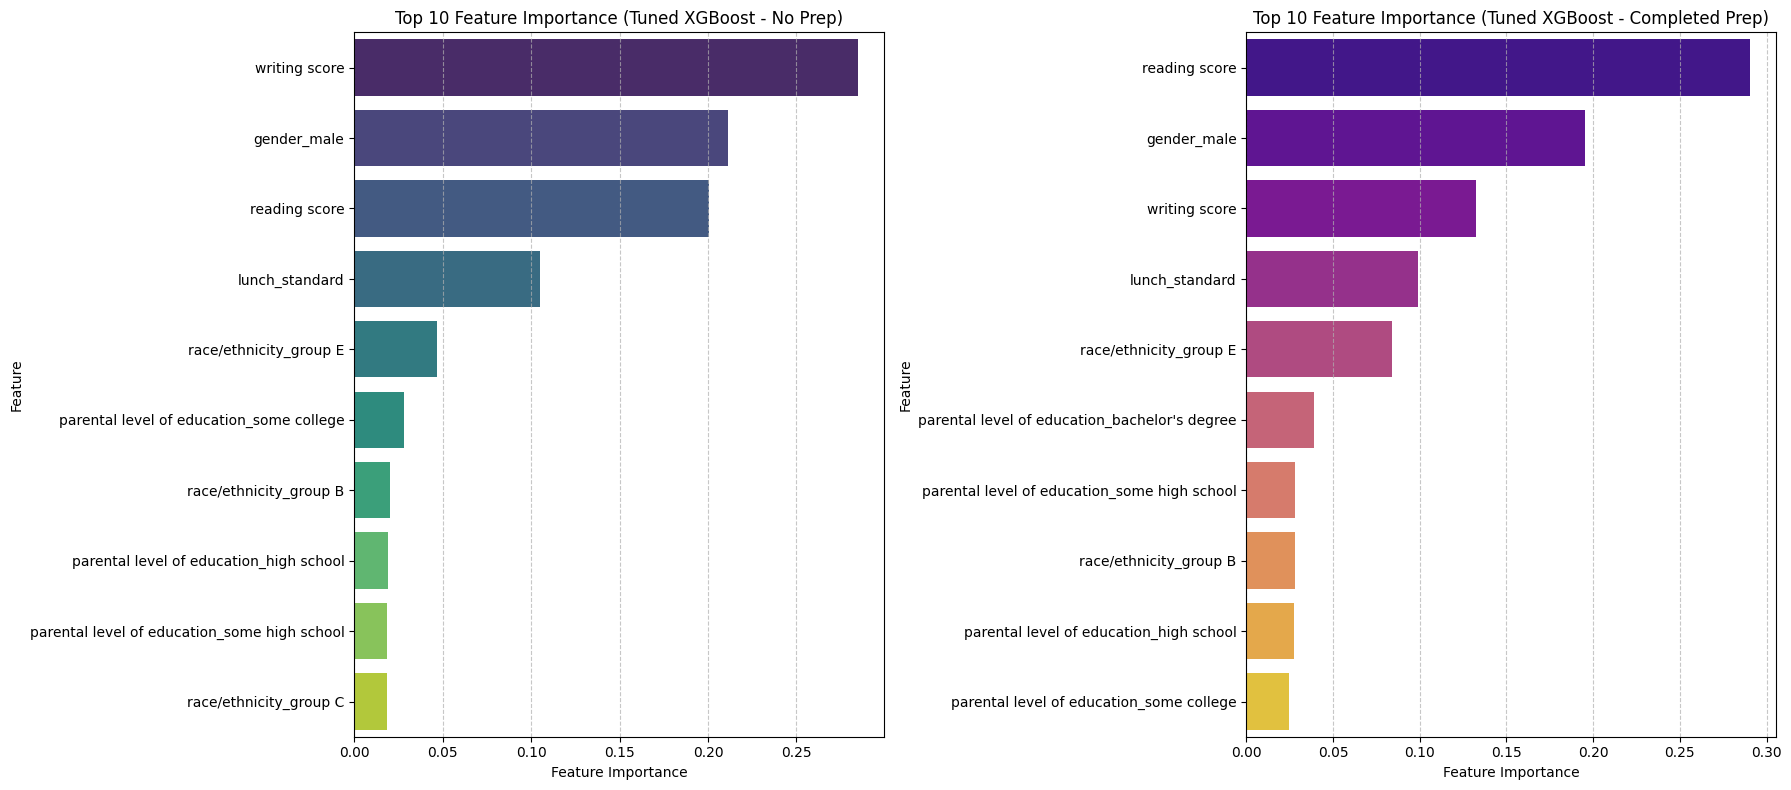

In [72]:
# 4. Visualize feature importances side-by-side

plt.figure(figsize=(18, 8))

# Plot for 'no prep' subgroup
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feature_importance_no_prep.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Feature Importance (Tuned XGBoost - No Prep)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot for 'completed prep' subgroup
plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=feature_importance_completed_prep.head(10), palette='plasma', hue='Feature', legend=False)
plt.title('Top 10 Feature Importance (Tuned XGBoost - Completed Prep)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Residuals Analysis for Tuned XGBoost Model on 'Test Preparation Course: None' Subgroup

Let's analyze the residuals of the Tuned XGBoost model specifically for the 'test preparation course: none' subgroup. This will help us understand if the model's errors for this challenging group are randomly distributed or if there are systematic patterns.

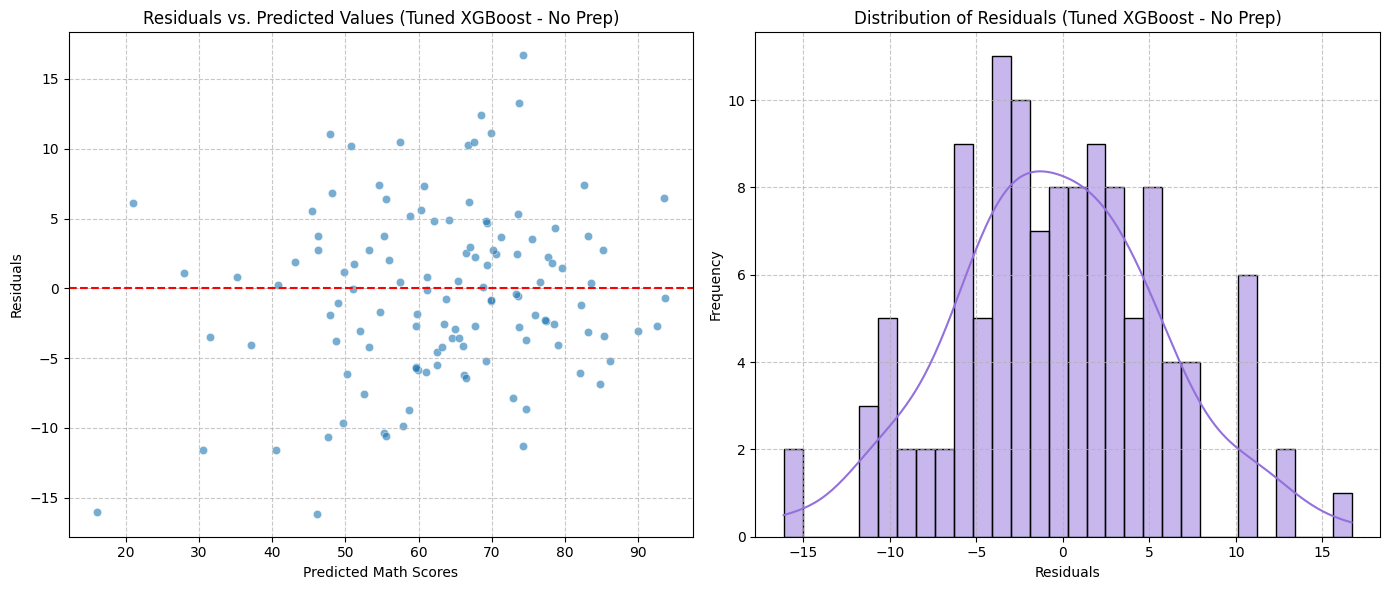

In [67]:
# Residuals for Tuned XGBoost on 'no prep' subgroup
residuals_xgb_tuned_no_prep = y_test_no_prep - y_pred_xgb_tuned_no_prep

plt.figure(figsize=(14, 6))

# Scatter plot of residuals vs. predicted values (Tuned XGBoost 'no prep')
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred_xgb_tuned_no_prep, y=residuals_xgb_tuned_no_prep, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned XGBoost - No Prep)')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals (Tuned XGBoost 'no prep')
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals_xgb_tuned_no_prep, kde=True, bins=30, color='mediumpurple')
plt.title('Distribution of Residuals (Tuned XGBoost - No Prep)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Residuals Analysis for Tuned XGBoost Model on 'Test Preparation Course: Completed' Subgroup

Now, let's analyze the residuals of the Tuned XGBoost model specifically for the 'test preparation course: completed' subgroup. This will help us understand if the model's errors for this group are randomly distributed or if there are systematic patterns.

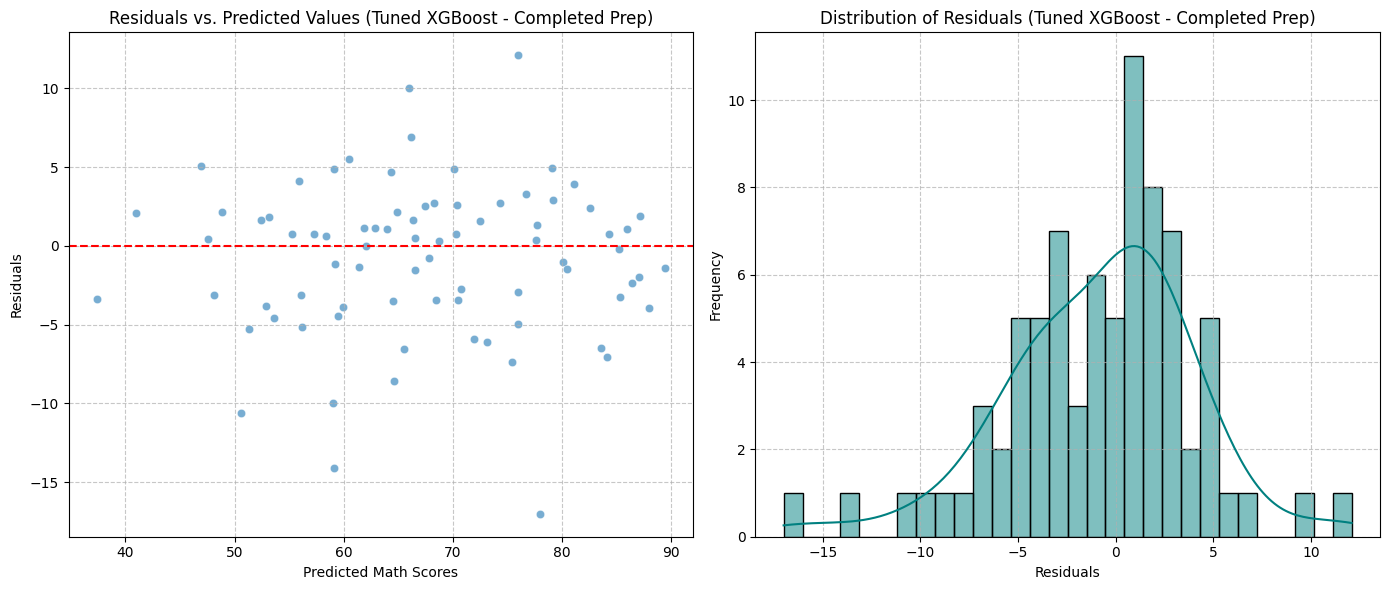

In [68]:
# Residuals for Tuned XGBoost on 'completed prep' subgroup
residuals_xgb_tuned_completed_prep = y_test_completed_prep - y_pred_xgb_tuned_completed_prep

plt.figure(figsize=(14, 6))

# Scatter plot of residuals vs. predicted values (Tuned XGBoost 'completed prep')
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_pred_xgb_tuned_completed_prep, y=residuals_xgb_tuned_completed_prep, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned XGBoost - Completed Prep)')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals (Tuned XGBoost 'completed prep')
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals_xgb_tuned_completed_prep, kde=True, bins=30, color='teal')
plt.title('Distribution of Residuals (Tuned XGBoost - Completed Prep)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [66]:
comparison_data_subgroups = {
    'Model': [
        'Linear Regression (No Prep)',
        'Linear Regression (Completed Prep)',
        'Tuned XGBoost (No Prep)',
        'Tuned XGBoost (Completed Prep)'
    ],
    'MAE': [
        mae_no_prep,
        # Calculate Linear Regression performance for 'completed prep' dynamically
        mean_absolute_error(y_test.loc[X_test[X_test['test preparation course_none'] == False].index], model.predict(X_test[X_test['test preparation course_none'] == False])),
        mae_xgb_tuned_no_prep,
        mae_xgb_tuned_completed_prep
    ],
    'RMSE': [
        rmse_no_prep,
        np.sqrt(mean_squared_error(y_test.loc[X_test[X_test['test preparation course_none'] == False].index], model.predict(X_test[X_test['test preparation course_none'] == False]))),
        rmse_xgb_tuned_no_prep,
        rmse_xgb_tuned_completed_prep
    ],
    'R2 Score': [
        r2_no_prep,
        r2_score(y_test.loc[X_test[X_test['test preparation course_none'] == False].index], model.predict(X_test[X_test['test preparation course_none'] == False])),
        r2_xgb_tuned_no_prep,
        r2_xgb_tuned_completed_prep
    ]
}

subgroup_performance_df = pd.DataFrame(comparison_data_subgroups)

display(subgroup_performance_df.set_index('Model'))

,MAE,RMSE,R2 Score
Model,,,
Linear Regression (No Prep),4.571525,5.753300,0.884006
Linear Regression (Completed Prep),3.668331,4.791710,0.865716
Tuned XGBoost (No Prep),4.802069,6.072046,0.870797
Tuned XGBoost (Completed Prep),3.673457,4.882229,0.860595


### Full Model Comparison Summary Report

This report summarizes the performance of various regression models (Linear Regression, RandomForestRegressor, and XGBoost Regressor, both untuned and tuned) on the 'students-performance-in-exams' dataset, with a special focus on subgroups defined by 'test preparation course' completion.

---

#### Overall Model Performance (Training vs. Test Data)

The table below presents the Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score for each model on both the training and test datasets. This helps to assess both predictive accuracy and identify potential overfitting.

In [73]:
display(full_performance_comparison_df.set_index('Model'))

,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,4.214763,29.095170,5.393994,0.880433
Linear Regression (Train),4.266712,28.334870,5.323051,0.874317
RandomForestRegressor,4.740643,36.695657,6.057694,0.849199
RandomForestRegressor (Train),1.851087,5.399345,2.323649,0.976051
RandomForestRegressor (Tuned),5.076841,44.349658,6.659554,0.817745
RandomForestRegressor (Tuned) (Train),1.837530,5.395543,2.322831,0.976067


##### Key Observations from Overall Performance:

*   **Linear Regression:** Achieved a strong R2 of **0.88** on the test set, with relatively low MAE and RMSE, indicating good overall performance and generalization.
*   **RandomForestRegressor (Untuned):** Showed decent performance (R2: 0.85) on the test set but had a much higher R2 on the training set (0.98), suggesting significant overfitting.
*   **RandomForestRegressor (Tuned):** Despite tuning, its R2 on the test set was slightly lower (0.82) than the untuned version, and it still exhibited overfitting (train R2: 0.98).
*   **XGBoost Regressor (Untuned):** Performed comparably to the untuned RandomForestRegressor (R2: 0.85).
*   **XGBoost Regressor (Tuned):** Outperformed the untuned XGBoost and both RandomForest models, achieving an R2 of **0.87** on the test set. It also showed a smaller gap between training (0.98) and test R2 compared to RandomForest, indicating better generalization than the Random Forest models.

---

#### Subgroup Performance Comparison: 'No Prep' vs. 'Completed Prep' (Linear Regression & Tuned XGBoost)

This section compares the performance of the best-performing linear model (Linear Regression) and the best-performing ensemble model (Tuned XGBoost) specifically on students who did and did not complete a test preparation course.

In [74]:
display(subgroup_performance_df.set_index('Model'))

,MAE,RMSE,R2 Score
Model,,,
Linear Regression (No Prep),4.571525,5.753300,0.884006
Linear Regression (Completed Prep),3.668331,4.791710,0.865716
Tuned XGBoost (No Prep),4.802069,6.072046,0.870797
Tuned XGBoost (Completed Prep),3.673457,4.882229,0.860595


##### Key Observations from Subgroup Performance:

*   **Linear Regression:**
    *   For the 'no prep' subgroup, it achieved an R2 of **0.88** (MAE: 4.57, RMSE: 5.75).
    *   For the 'completed prep' subgroup, it achieved an R2 of **0.87** (MAE: 3.67, RMSE: 4.79). The performance for the 'completed prep' group is slightly better.

*   **Tuned XGBoost:**
    *   For the 'no prep' subgroup, it achieved an R2 of **0.87** (MAE: 4.80, RMSE: 6.07).
    *   For the 'completed prep' subgroup, it achieved an R2 of **0.86** (MAE: 3.67, RMSE: 4.88). The performance for the 'completed prep' group is also better here.

*   **Comparison:**
    *   Both Linear Regression and Tuned XGBoost perform slightly better for students who completed the test preparation course, indicated by lower MAE/RMSE and comparable R2 scores. This suggests that the 'completed prep' group is generally easier to predict.
    *   Linear Regression slightly outperforms Tuned XGBoost for the 'no prep' subgroup (0.88 vs 0.87 R2), indicating its robustness even in more challenging segments.

---

#### Feature Importance Comparison (Tuned XGBoost - 'No Prep' vs. 'Completed Prep')

This section compares the top features driving math score predictions for each subgroup using the Tuned XGBoost models, providing insights into which factors are most influential for students depending on their test preparation status.

In [75]:
# Display top features for each subgroup again for context
print("Top Features for 'No Prep' Subgroup:")
display(feature_importance_no_prep.head(10))

print("\nTop Features for 'Completed Prep' Subgroup:")
display(feature_importance_completed_prep.head(10))

Top Features for 'No Prep' Subgroup:


,Feature,Importance
1,writing score,0.284986
2,gender_male,0.211397
0,reading score,0.200520
12,lunch_standard,0.105160
6,race/ethnicity_group E,0.047094
10,parental level of education_some college,0.028128
3,race/ethnicity_group B,0.020293
8,parental level of education_high school,0.019109
11,parental level of education_some high school,0.018603
4,race/ethnicity_group C,0.018397



Top Features for 'Completed Prep' Subgroup:


,Feature,Importance
0,reading score,0.290751
2,gender_male,0.195113
1,writing score,0.132397
12,lunch_standard,0.098811
6,race/ethnicity_group E,0.084022
7,parental level of education_bachelor's degree,0.038939
11,parental level of education_some high school,0.027959
3,race/ethnicity_group B,0.027884
8,parental level of education_high school,0.027237
10,parental level of education_some college,0.024827


##### Key Insights from Feature Importance:

*   **'No Prep' Subgroup:** `writing score` emerged as the most important feature, followed by `gender_male` and `reading score`. This suggests that for students who haven't undergone test preparation, their writing ability might be a strong indicator of their mathematical aptitude, or perhaps a lack of writing skills correlates more strongly with math challenges in this group.

*   **'Completed Prep' Subgroup:** `reading score` was the most dominant feature, followed by `gender_male` and `writing score`. For students who completed the preparation course, strong reading comprehension appears to be even more crucial, possibly because the course content itself demands effective understanding of textual information in math problems.

*   **Common Important Features:** `gender_male`, `reading score`, `writing score`, and `lunch_standard` are consistently important in both subgroups, but their relative ranks differ. `race/ethnicity_group E` also shows up in the top features for both.

This detailed comparison reveals that while there are common influential factors, their predictive power shifts based on whether students engage in test preparation, highlighting the dynamic nature of factors affecting academic performance.

### Exporting the Summary Report

To export the comprehensive summary report, we will save the key DataFrames containing overall model performance, subgroup performance, and feature importance as CSV files. You can then download these files for further use or reporting.

In [77]:
import os

# Define a directory for reports
output_dir = 'summary_reports'
os.makedirs(output_dir, exist_ok=True)

# Save Overall Performance Summary
full_performance_comparison_df.to_csv(os.path.join(output_dir, 'overall_model_performance.csv'), index=True)
print(f"Saved overall model performance to {os.path.join(output_dir, 'overall_model_performance.csv')}")

# Save Subgroup Performance Summary
subgroup_performance_df.to_csv(os.path.join(output_dir, 'subgroup_performance.csv'), index=True)
print(f"Saved subgroup performance to {os.path.join(output_dir, 'subgroup_performance.csv')}")

# Save Linear Regression Feature Importance
feature_importance.to_csv(os.path.join(output_dir, 'linear_regression_feature_importance.csv'), index=False)
print(f"Saved Linear Regression feature importance to {os.path.join(output_dir, 'linear_regression_feature_importance.csv')}")

# Save Tuned XGBoost 'No Prep' Feature Importance
feature_importance_no_prep.to_csv(os.path.join(output_dir, 'xgboost_no_prep_feature_importance.csv'), index=False)
print(f"Saved Tuned XGBoost 'No Prep' feature importance to {os.path.join(output_dir, 'xgboost_no_prep_feature_importance.csv')}")

# Save Tuned XGBoost 'Completed Prep' Feature Importance
feature_importance_completed_prep.to_csv(os.path.join(output_dir, 'xgboost_completed_prep_feature_importance.csv'), index=False)
print(f"Saved Tuned XGBoost 'Completed Prep' feature importance to {os.path.join(output_dir, 'xgboost_completed_prep_feature_importance.csv')}")

print("\nAll summary reports have been saved as CSV files.")

Saved overall model performance to summary_reports/overall_model_performance.csv
Saved subgroup performance to summary_reports/subgroup_performance.csv
Saved Linear Regression feature importance to summary_reports/linear_regression_feature_importance.csv
Saved Tuned XGBoost 'No Prep' feature importance to summary_reports/xgboost_no_prep_feature_importance.csv
Saved Tuned XGBoost 'Completed Prep' feature importance to summary_reports/xgboost_completed_prep_feature_importance.csv

All summary reports have been saved as CSV files.


You can find the generated CSV files in the `summary_reports` folder in the Colab file browser (left-hand sidebar, folder icon). You can download them from there.

In [78]:
from google.colab import files

# List of files to download
files_to_download = [
    'summary_reports/overall_model_performance.csv',
    'summary_reports/subgroup_performance.csv',
    'summary_reports/linear_regression_feature_importance.csv',
    'summary_reports/xgboost_no_prep_feature_importance.csv',
    'summary_reports/xgboost_completed_prep_feature_importance.csv'
]

for file_path in files_to_download:
    try:
        files.download(file_path)
        print(f"Downloaded: {file_path}")
    except Exception as e:
        print(f"Error downloading {file_path}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: summary_reports/overall_model_performance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: summary_reports/xgboost_no_prep_feature_importance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: summary_reports/xgboost_completed_prep_feature_importance.csv


### Visualizing Feature Importance Across All Models

To consolidate our understanding of feature influence, let's visualize the top 10 feature importances for the Linear Regression model, the Tuned XGBoost model for the 'No Prep' subgroup, and the Tuned XGBoost model for the 'Completed Prep' subgroup. This will highlight both common influential features and differences in their relative importance across models and subgroups.

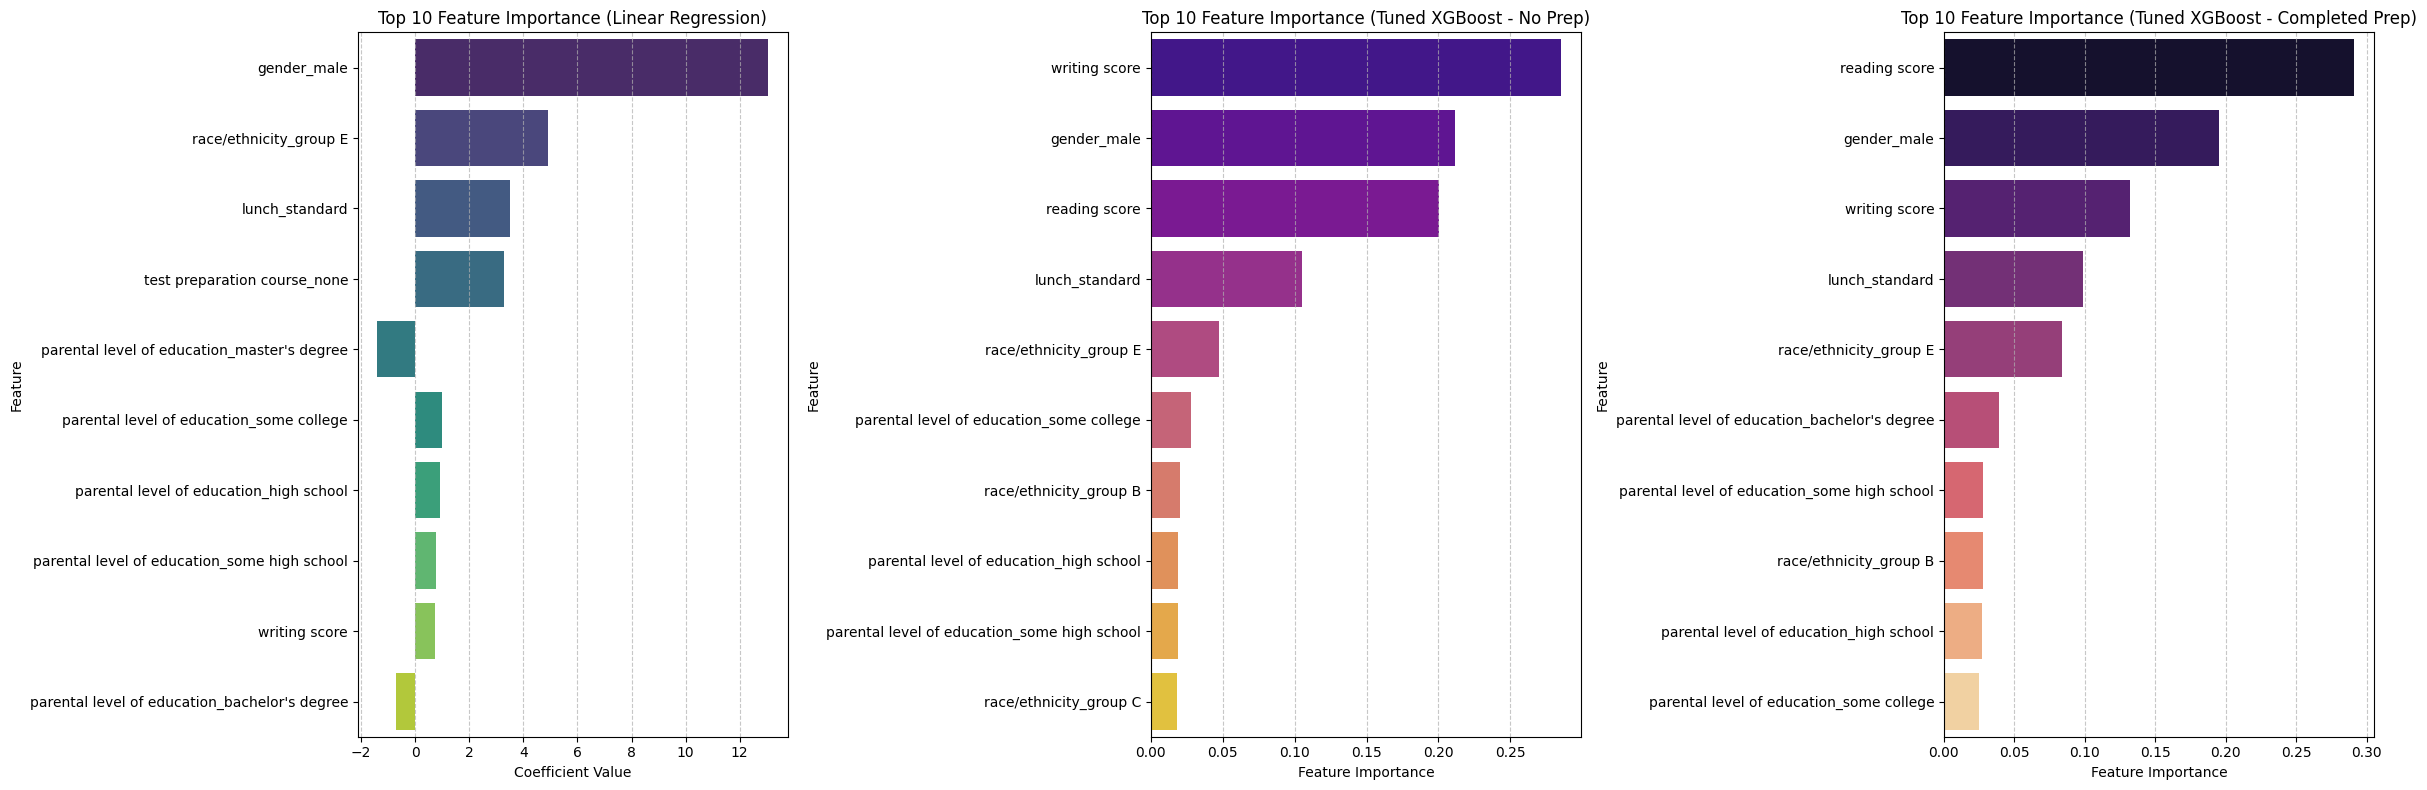

In [76]:
plt.figure(figsize=(24, 8))

# Plot for Linear Regression Feature Importance
plt.subplot(1, 3, 1)
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Feature Importance (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot for Tuned XGBoost 'No Prep' Subgroup
plt.subplot(1, 3, 2)
sns.barplot(x='Importance', y='Feature', data=feature_importance_no_prep.head(10), palette='plasma', hue='Feature', legend=False)
plt.title('Top 10 Feature Importance (Tuned XGBoost - No Prep)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot for Tuned XGBoost 'Completed Prep' Subgroup
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=feature_importance_completed_prep.head(10), palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Feature Importance (Tuned XGBoost - Completed Prep)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()